In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import  scipy
from scipy.stats.mstats import winsorize


In [ ]:
DATA_DIR = Path("../data")

In [ ]:
zproduct_df = pd.read_csv(
    DATA_DIR / "",
    encoding="latin1"
)PublicTablesForCarbonCatalogueDataDescriptor_v30Oct2021(Product Level Data).csv

In [ ]:
product_df.describe

<bound method NDFrame.describe of           *PCF-ID  Year of reporting *Stage-level CO2e available  \
0    10056-1-2014               2014                         Yes   
1    10056-1-2015               2015                         Yes   
2    10222-1-2013               2013                         Yes   
3    10261-1-2017               2017                         Yes   
4    10261-2-2017               2017                         Yes   
..            ...                ...                         ...   
861   9298-2-2014               2014                         Yes   
862   9298-3-2013               2013                         Yes   
863   9298-3-2014               2014                         Yes   
864   9792-1-2017               2017                          No   
865   9792-2-2017               2017                          No   

                    Product name (and functional unit)  \
0                             Frosted Flakes(R) Cereal   
1    Frosted Flakes, 23 oz, produ

In [ ]:
product_cleanf1 = product_df.copy()

In [ ]:
product_cleanf1.dtypes

*PCF-ID                                          str
Year of reporting                              int64
*Stage-level CO2e available                      str
Product name (and functional unit)               str
Product detail                                   str
Company                                          str
Country (where company is incorporated)          str
Company's GICS Industry Group                    str
Company's GICS Industry                          str
*Company's sector                                str
Product weight (kg)                          float64
*Source for product weight                       str
Product's carbon footprint (PCF, kg CO2e)    float64
*Carbon intensity                            float64
Protocol used for PCF                            str
Relative change in PCF vs previous               str
Company-reported reason for change               str
*Change reason category                          str
*%Upstream estimated from %Operations         

In [ ]:
product_cleanf1.duplicated().sum()

np.int64(0)

In [ ]:
missing = product_cleanf1.isnull().sum().sort_values(ascending=False)
missing

*Adjustments to raw data (if any)            679
Product detail                                10
*PCF-ID                                        0
*Stage-level CO2e available                    0
Year of reporting                              0
Company                                        0
Country (where company is incorporated)        0
Company's GICS Industry Group                  0
Product name (and functional unit)             0
Company's GICS Industry                        0
*Company's sector                              0
*Source for product weight                     0
Product weight (kg)                            0
*Carbon intensity                              0
Protocol used for PCF                          0
Relative change in PCF vs previous             0
Product's carbon footprint (PCF, kg CO2e)      0
Company-reported reason for change             0
*Change reason category                        0
*Upstream CO2e (fraction of total PCF)         0
*%Upstream estimated

In [ ]:
product_cleanf1.head(5)

,*PCF-ID,Year of reporting,*Stage-level CO2e available,Product name (and functional unit),Product detail,Company,Country (where company is incorporated),Company's GICS Industry Group,Company's GICS Industry,*Company's sector,...,Relative change in PCF vs previous,Company-reported reason for change,*Change reason category,*%Upstream estimated from %Operations,*Upstream CO2e (fraction of total PCF),*Operations CO2e (fraction of total PCF),*Downstream CO2e (fraction of total PCF),*Transport CO2e (fraction of total PCF),*EndOfLife CO2e (fraction of total PCF),*Adjustments to raw data (if any)
0,10056-1-2014,2014,Yes,Frosted Flakes(R) Cereal,"Frosted Flakes(R), 23 oz., Produced in Lancast...",Kellogg Company,USA,"Food, Beverage & Tobacco",Food Products,Food & Beverage,...,(not reported by company),N/a,N/a (no %change reported),No,57.50%,30.00%,12.50%,4.50%,(included in downstream but not reported separ...,Divided stage and total emissions by 1000 (bas...
1,10056-1-2015,2015,Yes,"Frosted Flakes, 23 oz, produced in Lancaster, ...",Cereal,Kellogg Company,USA,Food & Beverage Processing,Not used for 2015 reporting,Food & Beverage,...,(not reported by company),N/a,N/a (no %change reported),No,57.50%,30.00%,12.50%,4.50%,(included in downstream but not reported separ...,Divided stage and total emissions by 1000 (bas...
2,10222-1-2013,2013,Yes,Office Chair,Field not included in 2013 data,KNOLL INC,USA,Capital Goods,Building Products,Comm. equipm. & capital goods,...,(not reported by company),N/a,N/a (no previous data available),Yes,80.63%,17.36%,2.01%,(included in up/downstream but not reported se...,0.00%,"Changed %change to zero, according to field ""c..."
3,10261-1-2017,2017,Yes,Multifunction Printers,bizhub C458,"Konica Minolta, Inc.",Japan,Technology Hardware & Equipment,"Electronic Equipment, Instruments & Components","Computer, IT & telecom",...,(not reported by company),N/a,N/a (no previous data available),No,30.65%,5.51%,63.84%,1.01%,2.76%,NaN
4,10261-2-2017,2017,Yes,Multifunction Printers,bizhub C558,"Konica Minolta, Inc.",Japan,Technology Hardware & Equipment,"Electronic Equipment, Instruments & Components","Computer, IT & telecom",...,(not reported by company),N/a,N/a (no previous data available),No,25.08%,4.51%,70.41%,0.83%,2.26%,NaN


In [ ]:
product_cleanf1["*PCF-ID"].is_unique

True

In [ ]:
product_cleanf1 = product_cleanf1.drop(
    columns=[
             "*PCF-ID"
            ]
)

In [ ]:
product_cleanf1 = product_cleanf1.drop(
    columns=[
             "*Adjustments to raw data (if any)"
            ]
)

In [ ]:
product_cleanf1["Product detail"].value_counts(dropna=False).head(20)

Product detail
Field not included in 2013 data                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    97
BLANK                                                                                                                                                                                                                                                                                                                                                              

In [ ]:

product_cleanf1["Product detail"] = (
    product_cleanf1["Product detail"].replace(
        ["", " ", "??", "BLANK"],
        np.nan
    )
)

In [ ]:
product_cleanf1["Product detail"] = (
    product_cleanf1["Product detail"]
    .str.replace("?", "", regex=False)
)

In [ ]:
product_cleanf1["Product detail"].isna().sum()

np.int64(49)

In [ ]:
product_cleanf1["Product detail"].value_counts(dropna=False).head(20)

Product detail
Field not included in 2013 data                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    97
NaN                                                                                                                                                                                                                                                                                                                                                                

In [ ]:
product_cleanf1 = product_cleanf1.drop(columns=["Product detail"])


In [ ]:
product_cleanf1["Year of reporting"].value_counts().sort_index()

Year of reporting
2013    179
2014    190
2015    217
2016    218
2017     62
Name: count, dtype: int64

In [ ]:
cols = [
    "*Upstream CO2e (fraction of total PCF)",
    "*Operations CO2e (fraction of total PCF)",
    "*Downstream CO2e (fraction of total PCF)",
    "*Transport CO2e (fraction of total PCF)",
    "*EndOfLife CO2e (fraction of total PCF)"
]

product_cleanf1[cols].head(20)


,*Upstream CO2e (fraction of total PCF),*Operations CO2e (fraction of total PCF),*Downstream CO2e (fraction of total PCF),*Transport CO2e (fraction of total PCF),*EndOfLife CO2e (fraction of total PCF)
0,57.50%,30.00%,12.50%,4.50%,(included in downstream but not reported separ...
1,57.50%,30.00%,12.50%,4.50%,(included in downstream but not reported separ...
2,80.63%,17.36%,2.01%,(included in up/downstream but not reported se...,0.00%
3,30.65%,5.51%,63.84%,1.01%,2.76%
4,25.08%,4.51%,70.41%,0.83%,2.26%
5,20.05%,3.61%,76.34%,0.66%,1.80%
6,N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data)
7,N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data)
8,N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data)
9,N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data)


In [ ]:

replace_values = [
    "N/a (product with insufficient stage-level data)",   
]

stage_cols = [
    "*Upstream CO2e (fraction of total PCF)",
    "*Operations CO2e (fraction of total PCF)",
    "*Downstream CO2e (fraction of total PCF)",
    "*Transport CO2e (fraction of total PCF)",
    "*EndOfLife CO2e (fraction of total PCF)"
]

product_cleanf1[stage_cols] = product_cleanf1[stage_cols].replace(
    replace_values,
    np.nan
)

In [ ]:
for col in stage_cols:
    product_cleanf1[col] = product_cleanf1[col].str.replace("%", "", regex=False)

In [ ]:
for col in stage_cols:
    product_cleanf1[col] = pd.to_numeric(product_cleanf1[col], errors="coerce")

In [ ]:
product_cleanf1[stage_cols].head()

,*Upstream CO2e (fraction of total PCF),*Operations CO2e (fraction of total PCF),*Downstream CO2e (fraction of total PCF),*Transport CO2e (fraction of total PCF),*EndOfLife CO2e (fraction of total PCF)
0,57.50,30.00,12.50,4.50,NaN
1,57.50,30.00,12.50,4.50,NaN
2,80.63,17.36,2.01,NaN,0.00
3,30.65,5.51,63.84,1.01,2.76
4,25.08,4.51,70.41,0.83,2.26


In [ ]:
for col in stage_cols:
    product_cleanf1[col] = product_cleanf1[col] / 100

In [ ]:
for col in stage_cols:
    print(
        col,
        (product_cleanf1[col] < 0).sum(),
        (product_cleanf1[col] > 1).sum()
    )

*Upstream CO2e (fraction of total PCF) 0 0
*Operations CO2e (fraction of total PCF) 0 0
*Downstream CO2e (fraction of total PCF) 0 0
*Transport CO2e (fraction of total PCF) 0 0
*EndOfLife CO2e (fraction of total PCF) 0 0


In [ ]:
product_cleanf1[stage_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 5 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   *Upstream CO2e (fraction of total PCF)    421 non-null    float64
 1   *Operations CO2e (fraction of total PCF)  421 non-null    float64
 2   *Downstream CO2e (fraction of total PCF)  421 non-null    float64
 3   *Transport CO2e (fraction of total PCF)   298 non-null    float64
 4   *EndOfLife CO2e (fraction of total PCF)   180 non-null    float64
dtypes: float64(5)
memory usage: 34.0 KB


In [ ]:
product_cleanf1.dtypes

Year of reporting                              int64
*Stage-level CO2e available                      str
Product name (and functional unit)               str
Company                                          str
Country (where company is incorporated)          str
Company's GICS Industry Group                    str
Company's GICS Industry                          str
*Company's sector                                str
Product weight (kg)                          float64
*Source for product weight                       str
Product's carbon footprint (PCF, kg CO2e)    float64
*Carbon intensity                            float64
Protocol used for PCF                            str
Relative change in PCF vs previous               str
Company-reported reason for change               str
*Change reason category                          str
*%Upstream estimated from %Operations            str
*Upstream CO2e (fraction of total PCF)       float64
*Operations CO2e (fraction of total PCF)     f

In [ ]:
numeric_cols = [
    "Product weight (kg)",
    "Product's carbon footprint (PCF, kg CO2e)",
    "*Carbon intensity",
    "*Upstream CO2e (fraction of total PCF)",
    "*Operations CO2e (fraction of total PCF)",
    "*Downstream CO2e (fraction of total PCF)",
    "*Transport CO2e (fraction of total PCF)",
    "*EndOfLife CO2e (fraction of total PCF)"
]

for col in numeric_cols:
    print(f"\n{col}")
    print(f"Negative values: {(product_cleanf1[col] < 0).sum()}")
    print(f"Zero values: {(product_cleanf1[col] == 0).sum()}")


Product weight (kg)
Negative values: 0
Zero values: 0

Product's carbon footprint (PCF, kg CO2e)
Negative values: 0
Zero values: 0

*Carbon intensity
Negative values: 0
Zero values: 0

*Upstream CO2e (fraction of total PCF)
Negative values: 0
Zero values: 0

*Operations CO2e (fraction of total PCF)
Negative values: 0
Zero values: 5

*Downstream CO2e (fraction of total PCF)
Negative values: 0
Zero values: 80

*Transport CO2e (fraction of total PCF)
Negative values: 0
Zero values: 2

*EndOfLife CO2e (fraction of total PCF)
Negative values: 0
Zero values: 12


In [ ]:
stage_cols = [
    "*Upstream CO2e (fraction of total PCF)",
    "*Operations CO2e (fraction of total PCF)",
    "*Downstream CO2e (fraction of total PCF)",
    "*Transport CO2e (fraction of total PCF)",
    "*EndOfLife CO2e (fraction of total PCF)"
]

for col in stage_cols:
    invalid = ((product_cleanf1[col] < 0) | (product_cleanf1[col] > 100)).sum()
    print(f"{col}: {invalid} values outside 0–100")

*Upstream CO2e (fraction of total PCF): 0 values outside 0–100
*Operations CO2e (fraction of total PCF): 0 values outside 0–100
*Downstream CO2e (fraction of total PCF): 0 values outside 0–100
*Transport CO2e (fraction of total PCF): 0 values outside 0–100
*EndOfLife CO2e (fraction of total PCF): 0 values outside 0–100


In [ ]:
product_cleanf1[numeric_cols].describe()

,Product weight (kg),"Product's carbon footprint (PCF, kg CO2e)",*Carbon intensity,*Upstream CO2e (fraction of total PCF),*Operations CO2e (fraction of total PCF),*Downstream CO2e (fraction of total PCF),*Transport CO2e (fraction of total PCF),*EndOfLife CO2e (fraction of total PCF)
count,866.000000,8.660000e+02,866.000000,421.000000,421.000000,421.000000,298.000000,180.000000
mean,2806.548993,1.581525e+04,34.252968,0.445245,0.231332,0.323425,0.075488,0.038874
std,34405.725655,1.813733e+05,84.599082,0.308126,0.259239,0.337878,0.116045,0.085621
min,0.001270,4.000000e-04,0.110000,0.000100,0.000000,0.000000,0.000000,0.000000
25%,1.000000,7.000000e+00,1.320000,0.155500,0.030200,0.005500,0.009700,0.003200
50%,15.899207,1.111000e+02,5.400000,0.440500,0.126000,0.221000,0.032200,0.018750
75%,1000.000000,1.600000e+03,26.000000,0.680300,0.325700,0.595400,0.094375,0.036250
max,600000.000000,3.718044e+06,973.220000,0.998100,0.990900,0.999900,0.891000,0.651700


                                Outlier detection and Handeling

/tmp/ipykernel_2578/2514995624.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(product_cleanf1[col].dropna(), vert=False)


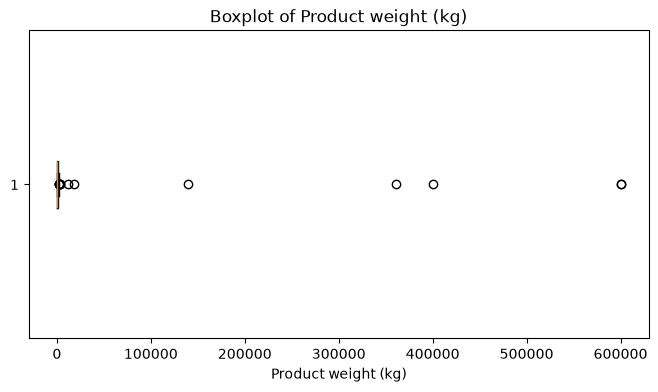

/tmp/ipykernel_2578/2514995624.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(product_cleanf1[col].dropna(), vert=False)


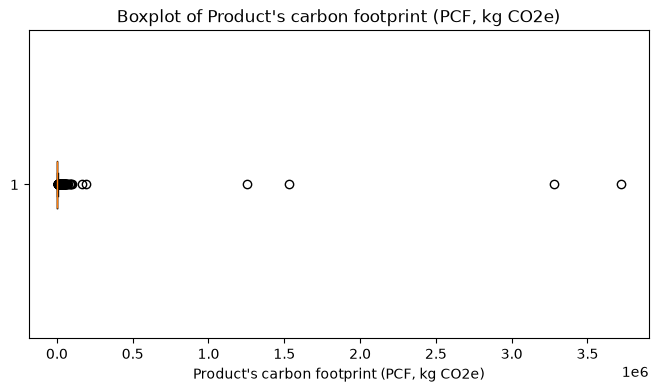

/tmp/ipykernel_2578/2514995624.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(product_cleanf1[col].dropna(), vert=False)


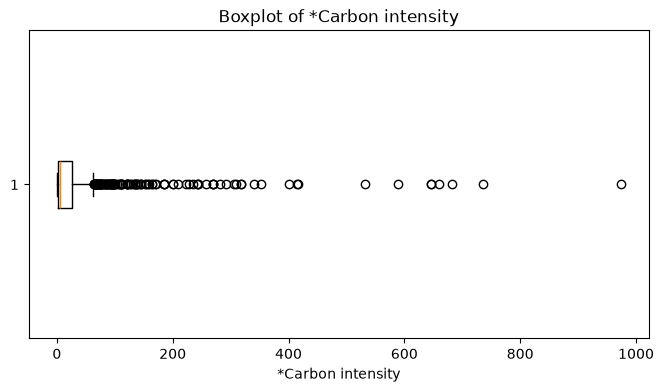

In [ ]:
outlier_cols = [
    "Product weight (kg)",
    "Product's carbon footprint (PCF, kg CO2e)",
    "*Carbon intensity"
]

for col in outlier_cols:
    plt.figure(figsize=(8,4))
    plt.boxplot(product_cleanf1[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [ ]:
def outlier_count(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return ((series < lower) | (series > upper)).sum()

outlier_cols = [
    "Product weight (kg)",
    "Product's carbon footprint (PCF, kg CO2e)",
    "*Carbon intensity"
]

for col in outlier_cols:
    print(f"{col}: {outlier_count(product_cleanf1[col])} outliers")

Product weight (kg): 13 outliers
Product's carbon footprint (PCF, kg CO2e): 122 outliers
*Carbon intensity: 122 outliers


In [ ]:
product_winsor = product_cleanf1.copy()

In [ ]:
product_winsor[outlier_cols].describe()

/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,Product weight (kg),"Product's carbon footprint (PCF, kg CO2e)",*Carbon intensity
count,866.000000,866.000000,866.000000
mean,374.405849,4699.183246,31.785889
std,639.001481,13544.927758,66.813045
min,0.008400,0.017000,0.140000
25%,1.000000,7.000000,1.320000
50%,15.899207,111.100000,5.400000
75%,1000.000000,1600.000000,26.000000
max,3500.000000,87589.364670,416.150000


Applying Winsorier

In [ ]:
for col in outlier_cols:
    product_winsor[col] = winsorize(
        product_winsor[col],
        limits=[0.01, 0.01]
    )

In [ ]:
product_winsor[outlier_cols].describe()

/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,Product weight (kg),"Product's carbon footprint (PCF, kg CO2e)",*Carbon intensity
count,866.000000,866.000000,866.000000
mean,374.405849,4699.183246,31.785889
std,639.001481,13544.927758,66.813045
min,0.008400,0.017000,0.140000
25%,1.000000,7.000000,1.320000
50%,15.899207,111.100000,5.400000
75%,1000.000000,1600.000000,26.000000
max,3500.000000,87589.364670,416.150000


/tmp/ipykernel_2578/3306604752.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(product_winsor[col], vert=False)


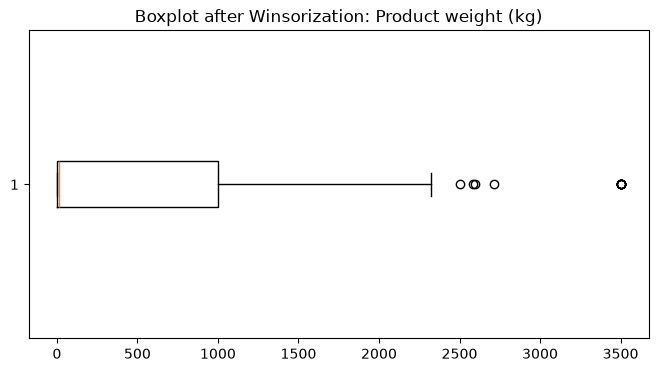

/tmp/ipykernel_2578/3306604752.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(product_winsor[col], vert=False)


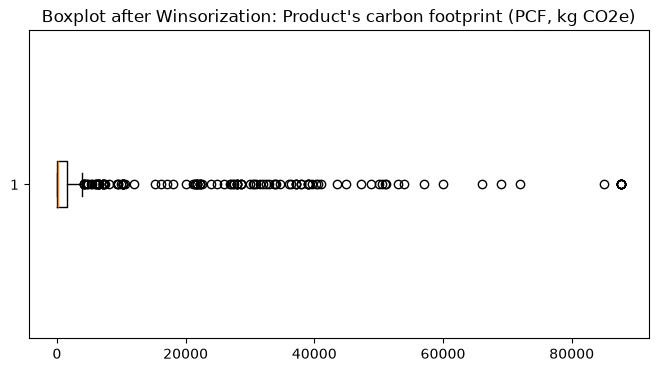

/tmp/ipykernel_2578/3306604752.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(product_winsor[col], vert=False)


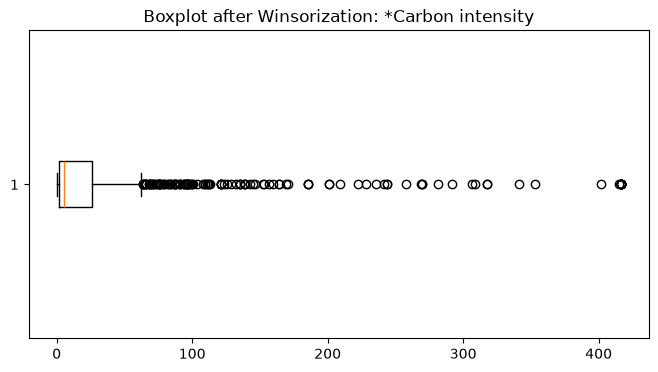

In [ ]:
for col in outlier_cols:
    plt.figure(figsize=(8,4))
    plt.boxplot(product_winsor[col], vert=False)
    plt.title(f"Boxplot after Winsorization: {col}")
    plt.show()

In [50]:
comparison = pd.DataFrame({
    "Before Max": product_cleanf1[outlier_cols].max(),
    "After Max": product_winsor[outlier_cols].max(),
    "Before Mean": product_cleanf1[outlier_cols].mean(),
    "After Mean": product_winsor[outlier_cols].mean()
})

comparison

,Before Max,After Max,Before Mean,After Mean
Product weight (kg),600000.00,600000.00,2806.548993,2806.548993
"Product's carbon footprint (PCF, kg CO2e)",3718044.00,3718044.00,15815.246783,15815.246783
*Carbon intensity,973.22,973.22,34.252968,34.252968


In [51]:
categorical_cols = [
    "*Stage-level CO2e available",
    "Country (where company is incorporated)",
    "Company's GICS Industry Group",
    "Company's GICS Industry",
    "*Company's sector",
    "*Source for product weight",
    "Protocol used for PCF",
    "Relative change in PCF vs previous",
    "*Change reason category",
    "*%Upstream estimated from %Operations"
]

for col in categorical_cols:
    print(f"\n{'='*80}")
    print(col)
    print(product_winsor[col].value_counts(dropna=False))


*Stage-level CO2e available
*Stage-level CO2e available
No     445
Yes    421
Name: count, dtype: int64

Country (where company is incorporated)
Country (where company is incorporated)
USA               305
Japan             110
Germany            67
Taiwan             60
Finland            35
Netherlands        35
United Kingdom     32
Switzerland        28
Sweden             26
Italy              23
South Korea        22
France             20
Brazil             17
India              16
Spain              13
South Africa       11
Belgium             8
China               6
Canada              6
Ireland             6
Australia           6
Malaysia            4
Chile               3
Colombia            2
Luxembourg          2
Lithuania           1
Indonesia           1
Greece              1
Name: count, dtype: int64

Company's GICS Industry Group
Company's GICS Industry Group
Technology Hardware & Equipment                                         195
Materials                          

In [53]:
product_winsor.to_csv(
    "/workspaces/pcf-quality-framework/BEACON-PCF/data/product_cleaned.csv",
    index=False
)